#langkah 1: impor dan dataset sintesis

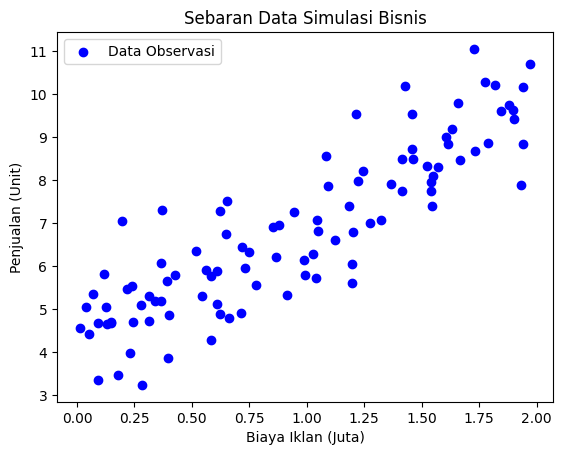

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Menyiapkan data (100 sampel)
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # Fitur: Biaya Iklan
y = 4 + 3 * X + np.random.randn(100, 1) # Target: Penjualan (dengan noise)

# Visualisasi data mentah
plt.scatter(X, y, color='blue', label='Data Observasi')
plt.xlabel('Biaya Iklan (Juta)')
plt.ylabel('Penjualan (Unit)')
plt.legend()
plt.title('Sebaran Data Simulasi Bisnis')
plt.show()

#Langkah 2: estimasi parameter dengan OLS (Analitik)

In [3]:
from sklearn.linear_model import LinearRegression
# Inisialisasi dan Training
lin_reg = LinearRegression()
lin_reg.fit(X, y)
# Menampilkan parameter yang ditemukan
print("--- Hasil OLS ---")
print(f"Intercept (Beta 0): {lin_reg.intercept_[0]}")
print(f"Slope (Beta 1): {lin_reg.coef_[0][0]}")

--- Hasil OLS ---
Intercept (Beta 0): 4.215096157546747
Slope (Beta 1): 2.7701133864384837


In [9]:
r2 = lin_reg.score(X, y)
print("R-Squared:", r2)

R-Squared: 0.7692735413614223


#Langkah 3 : estimasi parameter dengan SGD (iterratif)

In [5]:
from sklearn.linear_model import SGDRegressor
# Inisialisasi SGD dengan Learning Rate (eta0) = 0.1
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.1, random_state=42)
sgd_reg.fit(X, y.ravel()) # .ravel() mengubah matriks jadi array 1D
print("\n--- Hasil SGD ---")
print(f"Intercept (Beta 0): {sgd_reg.intercept_[0]}")
print(f"Slope (Beta 1): {sgd_reg.coef_[0]}")


--- Hasil SGD ---
Intercept (Beta 0): 4.244385627092402
Slope (Beta 1): 2.8242988001195513


# Langkah 4: visualisasi perbandingan garis regesi

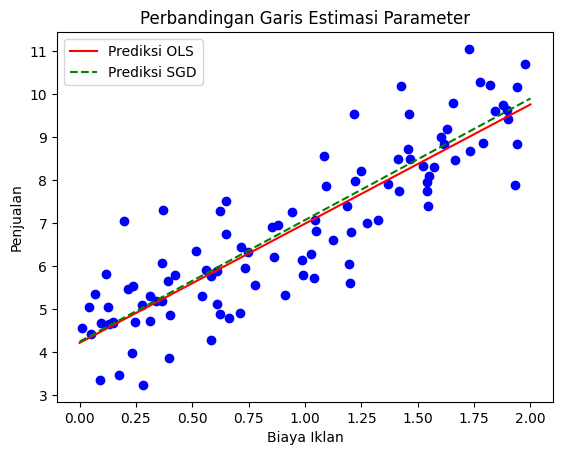

In [6]:
X_new = np.array([[0], [2]])
y_predict_ols = lin_reg.predict(X_new)
y_predict_sgd = sgd_reg.predict(X_new)
plt.scatter(X, y, color='blue')
plt.plot(X_new, y_predict_ols, "r-", label="Prediksi OLS")
plt.plot(X_new, y_predict_sgd, "g--", label="Prediksi SGD")
plt.xlabel("Biaya Iklan")
plt.ylabel("Penjualan")
plt.legend()
plt.title("Perbandingan Garis Estimasi Parameter")
plt.show()

In [8]:
from sklearn.metrics import mean_squared_error

# Prediksi
y_pred_ols = lin_reg.predict(X)
y_pred_sgd = sgd_reg.predict(X)

# Hitung MSE
mse_ols = mean_squared_error(y, y_pred_ols)
mse_sgd = mean_squared_error(y, y_pred_sgd)

print("MSE OLS:", mse_ols)
print("MSE SGD:", mse_sgd)

MSE OLS: 0.8065845639670531
MSE SGD: 0.8140525291701088
